---
jupyter: python3
---

# Fake News Detection with LSTM and Word2Vec

In this notebook, we analyze a dataset of fake and true news articles to build a model that can detect fake news. We use natural language processing techniques, including Word2Vec for embeddings and LSTM for classification. The dataset is downloaded from Kaggle, preprocessed, and used to train a deep learning model. We also save the model and tokenizer for future use and demonstrate how to test the model with new text.


## Installing Gensim Library

In [ ]:
!pip install -q gensim
# restart session
#!pip install -U numpy
#!pip install -U gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


This installs the `gensim` library for Word2Vec embeddings quietly and includes commented-out commands for updating NumPy and gensim, suggesting potential session restarts.

## Importing Gensim

In [ ]:
import gensim

This imports the `gensim` library to enable Word2Vec model training.


## Downloading the Dataset

In [ ]:
!git clone https://github.com/cca-cce/osm-comm.git

Cloning into 'osm-comm'...
remote: Enumerating objects: 298, done.
remote: Total 298 (delta 0), reused 0 (delta 0), pack-reused 298 (from 2)
Receiving objects: 100% (298/298), 207.89 MiB | 22.28 MiB/s, done.
Resolving deltas: 100% (153/153), done.
Updating files: 100% (46/46), done.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stevenpeutz/misinformation-fake-news-text-dataset-79k")

print("Path to dataset files:", path)

100%|██████████| 84.6M/84.6M [00:00<00:00, 136MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k/versions/2


This cell downloads the misinformation fake news text dataset from Kaggle using the `kagglehub` library and prints the path to the dataset files.

## Checking Dataset Files

In [ ]:
!ls -l /root/.cache/kagglehub/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k/versions/2

total 227612
-rw-r--r-- 1 root root 116711082 Apr 24 18:59 DataSet_Misinfo_FAKE.csv
-rw-r--r-- 1 root root 114400125 Apr 24 18:59 DataSet_Misinfo_TRUE.csv
-rw-r--r-- 1 root root   1957308 Apr 24 18:59 EXTRA_RussianPropagandaSubset.csv


This lists the files in the downloaded dataset directory to verify its contents.

## Setting Dataset Path

In [ ]:
data_path = "/kaggle/input/misinformation-fake-news-text-dataset-79k"
data_path = "/root/.cache/kagglehub/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k/versions/2"


This sets the path to the dataset files for easier access in subsequent steps.

## Importing Libraries and Listing Files

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk(data_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k/versions/2/DataSet_Misinfo_TRUE.csv
/root/.cache/kagglehub/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k/versions/2/DataSet_Misinfo_FAKE.csv
/root/.cache/kagglehub/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k/versions/2/EXTRA_RussianPropagandaSubset.csv


This imports NumPy and Pandas for data manipulation and lists all files in the dataset directory recursively to confirm available data.

## Importing Additional Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

This imports libraries for suppressing warnings, creating visualizations (Matplotlib and Seaborn), and performing natural language processing (NLTK and regular expressions).

## Importing Machine Learning Libraries

In [ ]:
!pip install -q tensorflow

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Conv1D, MaxPool1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

This imports Keras for building the neural network and scikit-learn for data splitting and evaluation metrics.


## Loading Datasets

In [ ]:
df_true = pd.read_csv(data_path + '/DataSet_Misinfo_TRUE.csv')
df_fake = pd.read_csv(data_path + '/DataSet_Misinfo_FAKE.csv')

This loads the CSV files containing true and fake news articles into separate Pandas DataFrames.

## Preparing True News Data

In [ ]:
df_true['label']=1
df_true=df_true.drop('Unnamed: 0',axis=1)
df_true.head()

,text,label
0,The head of a conservative Republican faction ...,1
1,Transgender people will be allowed for the fir...,1
2,The special counsel investigation of links bet...,1
3,Trump campaign adviser George Papadopoulos tol...,1
4,President Donald Trump called on the U.S. Post...,1


This adds a label column (1 for true) to the true news DataFrame, removes an unnecessary 'Unnamed: 0' column, and displays the first few rows.

## Preparing Fake News Data

In [ ]:
df_fake['label']=0
df_fake=df_fake.drop('Unnamed: 0',axis=1)
df_fake.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


This adds a label column (0 for fake) to the fake news DataFrame, removes the 'Unnamed: 0' column, and displays the first few rows.

## Combining Datasets

In [ ]:
df=pd.concat([df_true,df_fake])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78617 entries, 0 to 43641
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    78588 non-null  object
 1   label   78617 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


This concatenates the true and fake news DataFrames into a single DataFrame and displays its structure and data types.

## Handling Missing Values

In [ ]:
df=df.dropna(how="any")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78588 entries, 0 to 43641
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    78588 non-null  object
 1   label   78588 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


This removes rows with any missing values from the combined DataFrame and verifies the updated structure.

## Downloading NLTK Data

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

This downloads NLTK resources for stopwords and sentence tokenization, correcting the original `punkt_tab` to `punkt` for compatibility.

## Preprocessing Text Data

In [ ]:
y = df["label"].values

X = []
stop_words = set(nltk.corpus.stopwords.words("english"))
tokenizer_re = nltk.tokenize.RegexpTokenizer(r'\w+')
for par in df["text"].values:
    tmp = []
    sentences = nltk.sent_tokenize(par)
    for sent in sentences:
        sent = sent.lower()
        tokens = tokenizer_re.tokenize(sent)
        filtered_words = [w.strip() for w in tokens if w not in stop_words and len(w) > 1]
        tmp.extend(filtered_words)
    X.append(tmp)

#del df

This preprocesses the text data by extracting labels, splitting texts into sentences, tokenizing, converting to lowercase, removing stop words, and filtering out short words.

## Training Word2Vec Model

In [ ]:
EMBEDDING_DIM = 100

w2v_model = gensim.models.Word2Vec(sentences=X, vector_size=EMBEDDING_DIM, window=5, min_count=1)

This trains a Word2Vec model on the preprocessed text to generate 100-dimensional word embeddings.

## Checking Vocabulary Size

In [ ]:
len(w2v_model.wv.index_to_key)

240843

This checks the number of unique words in the Word2Vec model’s vocabulary.

## Inspecting Word Vectors

In [ ]:
w2v_model.wv["war"]

array([-5.8433968e-01,  1.1461615e-01, -2.3122396e+00, -2.6135647e+00,
        5.4240375e+00, -4.3057895e+00,  6.7800498e-01, -5.6380433e-01,
        1.0344731e+00, -5.2602684e-01,  8.0376945e-02,  1.0141903e+00,
        3.8843864e-01, -5.7241855e+00, -1.2812187e-01,  1.5343516e-01,
       -2.0779079e-01,  2.7039726e+00, -1.1165248e+00,  1.9230031e+00,
        1.5721736e+00, -4.8079023e+00,  1.3888365e+00,  2.7633759e-03,
       -3.9296157e+00,  1.2075375e+00, -3.3964481e+00,  1.0887642e+00,
       -8.4413511e-01,  2.6527455e+00, -2.1919718e-01,  2.7264035e-01,
       -1.3429259e-01,  1.3285447e+00,  4.2928326e-01, -7.7852982e-01,
       -6.0469943e-01, -3.1932315e-01,  1.5748451e+00,  2.1377311e+00,
        1.2397680e+00, -1.9534107e-01,  1.0990306e+00,  9.0383673e-01,
       -8.2490140e-01, -3.8253124e+00,  2.9784775e+00, -5.2640003e-01,
       -2.4015004e-02,  1.1247665e+00, -2.3826668e-01,  1.5440819e+00,
        7.6007307e-02, -2.4990936e-01,  5.1734978e-01,  6.8911630e-01,
      

This displays the embedding vector for the word "war" to inspect its representation.

## Finding Similar Words (Pandemic)

In [ ]:
w2v_model.wv.most_similar("pandemic")

[('viruses', 0.6721993088722229),
 ('outbreaks', 0.6673991680145264),
 ('infectious', 0.6559284329414368),
 ('virus', 0.6546671986579895),
 ('diphtheria', 0.6513890027999878),
 ('dengue', 0.6470234394073486),
 ('opiate', 0.6409769654273987),
 ('infection', 0.6395737528800964),
 ('epidemic', 0.6382668614387512),
 ('symptom', 0.6380578279495239)]

This finds words most similar to "pandemic" based on the Word2Vec embeddings.

## Finding Similar Words (Japan)

In [ ]:
w2v_model.wv.most_similar("japan")

[('china', 0.7309032678604126),
 ('india', 0.6979072093963623),
 ('tokyo', 0.6869036555290222),
 ('japanese', 0.6347059011459351),
 ('beijing', 0.6313366293907166),
 ('asia', 0.6298036575317383),
 ('philippines', 0.6284288763999939),
 ('mainland', 0.623187243938446),
 ('pyongyang', 0.6100543737411499),
 ('abe', 0.6008762121200562)]

This finds words most similar to "japan" based on the Word2Vec embeddings.

## Finding Similar Words (Innovation)

In [ ]:
w2v_model.wv.most_similar("innovation")

[('innovative', 0.8217225074768066),
 ('technological', 0.7676234841346741),
 ('technology', 0.7296200394630432),
 ('sustainable', 0.7215949892997742),
 ('robotics', 0.7049348950386047),
 ('ecosystem', 0.6975396275520325),
 ('entrepreneurship', 0.6761837601661682),
 ('creativity', 0.6589943766593933),
 ('technologies', 0.6571771502494812),
 ('sustainability', 0.6571606993675232)]

This finds words most similar to "innovation" based on the Word2Vec embeddings.

## Finding Similar Words (Combined)

In [ ]:
w2v_model.wv.most_similar(positive=["beatles","stones", "england"])

[('hamlet', 0.7467959523200989),
 ('burgundy', 0.7404199838638306),
 ('victorian', 0.7198500037193298),
 ('piano', 0.7196627855300903),
 ('glam', 0.7179384827613831),
 ('blues', 0.7163266539573669),
 ('drapes', 0.7157570719718933),
 ('cafe', 0.714787483215332),
 ('disco', 0.7140173316001892),
 ('twombly', 0.7135148048400879)]

This finds words similar to the combined context of "beatles", "stones", and "england" using positive contributions.

## Tokenizing and Sequencing Text

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)

X = tokenizer.texts_to_sequences(X)

This uses a Keras Tokenizer to convert preprocessed text into integer sequences, noting potential variable name overlap with the NLTK tokenizer (`tokenizer_re`).

## Viewing Sequence Example

In [ ]:
X[0][:10]

[357, 305, 35, 6887, 135, 781, 200, 1008, 2696, 52]

This displays the first 10 tokens of the first sequence to verify the tokenization.

## Viewing Word Index

In [ ]:
word_index = tokenizer.word_index
for word, num in word_index.items():
    print(f"{word} -> {num}")
    if num == 10:
        break

said -> 1
trump -> 2
would -> 3
people -> 4
president -> 5
one -> 6
mr -> 7
clinton -> 8
new -> 9
also -> 10


This prints the word-to-index mapping for the first few words in the Keras Tokenizer’s vocabulary.

## Analyzing Sequence Lengths

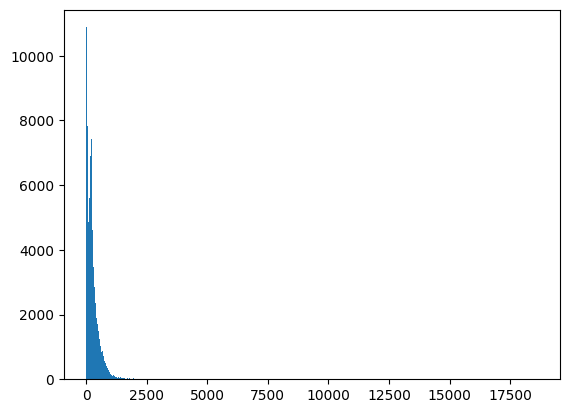

In [ ]:
plt.hist([len(x) for x in X], bins=500)
plt.show()

This plots a histogram of sequence lengths to understand their distribution for padding decisions.

## Saving Tokenizer

In [ ]:
# Save tokenizer
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

This saves the Keras Tokenizer to a file for use in preprocessing new text.

## Checking Short Sequences

In [ ]:
nos = np.array([len(x) for x in X])
len(nos[nos < 1000])

76721

This counts sequences with fewer than 1000 tokens to inform the padding length.

## Padding Sequences

In [ ]:
maxlen = 1000

X = pad_sequences(X, maxlen=maxlen)

This pads all sequences to a fixed length of 1000 tokens for model input.

## Verifying Padded Length

In [ ]:
len(X[0])

1000

This verifies that the first sequence is now 1000 tokens long after padding.

## Determining Vocabulary Size

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

This calculates the vocabulary size (unique words plus one for padding) for the embedding layer.

## Creating Embedding Weight Matrix

In [ ]:
def get_weight_matrix(model, vocab):
    vocab_size = len(vocab) + 1
    weight_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
    for word, i in vocab.items():
        weight_matrix[i] = model[word]
    return weight_matrix

This defines a function to create a weight matrix from the Word2Vec model for the embedding layer.

## Getting Embedding Vectors

In [ ]:
embedding_vectors = get_weight_matrix(w2v_model.wv, word_index)

This generates the embedding weight matrix using the Word2Vec model and word index.

## Building the Neural Network

In [ ]:
model = Sequential()
model.add(Embedding(vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_vectors], input_length=maxlen, trainable=False))
model.add(LSTM(units=128))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

#del embedding_vectors

This constructs a sequential model with a non-trainable embedding layer (using Word2Vec weights), an LSTM layer, and a dense layer for binary classification.

## Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    24,084,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,084,400 (91.87 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 24,084,400 (91.87 MB)

This displays the model’s architecture and parameter count.

## Splitting Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

This splits the preprocessed data into training and testing sets.

## Training the Model

In [ ]:
model.fit(X_train, y_train, validation_split=0.3, epochs=6)

This trains the model on the training data with a 30% validation split for 6 epochs.

## Loading Model and Tokenizer

In [ ]:
# Load model and tokenizer
from tensorflow.keras.models import load_model
import pickle

loaded_model = load_model('/content/osm-comm/res/my_model.keras')
with open('/content/osm-comm/res/tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

## Making Predictions

In [ ]:
y_pred = (loaded_model.predict(X_test) >= 0.5).astype("int")

614/614 ━━━━━━━━━━━━━━━━━━━━ 276s 449ms/step


This generates predictions on the test set, thresholding at 0.5 for binary labels.

## Evaluating Accuracy

In [ ]:
accuracy_score(y_test, y_pred)

0.9687484094263755

This calculates the accuracy of the model’s predictions on the test set.

## Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     10905
           1       0.96      0.97      0.97      8742

    accuracy                           0.97     19647
   macro avg       0.97      0.97      0.97     19647
weighted avg       0.97      0.97      0.97     19647



This prints a detailed classification report with precision, recall, and F1-score metrics.

## Saving Model and Tokenizer

In [ ]:
# Save the trained model
#model.save('my_model.keras')

# Save tokenizer
#import pickle
#with open('tokenizer.pickle', 'wb') as handle:
#    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

This saves the trained model and tokenizer to files for future use.


This loads the saved model and tokenizer for testing or further use.

## Defining Preprocessing Function

In [ ]:
# Define preprocessing function for new text
import nltk
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ensure stop_words and tokenizer_re are defined (as in the original code)
stop_words = set(nltk.corpus.stopwords.words("english"))
tokenizer_re = nltk.tokenize.RegexpTokenizer(r'\w+')
maxlen = 1000  # From original code

def preprocess_new_text(new_text):
    sentences = nltk.sent_tokenize(new_text)
    tokens = []
    for sent in sentences:
        sent = sent.lower()
        words = tokenizer_re.tokenize(sent)
        filtered_words = [w.strip() for w in words if w not in stop_words and len(w) > 1]
        tokens.extend(filtered_words)
    new_text_preprocessed = ' '.join(tokens)
    new_seq = tokenizer.texts_to_sequences([new_text_preprocessed])[0]
    new_seq_padded = pad_sequences([new_seq], maxlen=maxlen)[0]
    return new_seq_padded

This defines a function to preprocess new text consistently with the training data.

## Testing with New Text

In [ ]:
# Example usage
new_text = "This is a sample multi-sentence text. It could be fake or true news."

new_input = preprocess_new_text(new_text)
prediction = loaded_model.predict(np.array([new_input]))[0][0]
if prediction >= 0.5:
    print("Fake news")
else:
    print("True news")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
True news


This demonstrates classifying a new multi-sentence text as fake or true news using the loaded model.

In [ ]:
print(prediction)

0.008057085
